In [1]:
import matplotlib
matplotlib.use('TkAgg'),
import matplotlib.pyplot as plt
%matplotlib widget

In [78]:
from pyorbit.subroutines.common import np
import pyorbit.subroutines.constants as constants
import pyorbit.subroutines.kepler_exo as kepler_exo
from pyorbit.models.abstract_model import AbstractModel
from pyorbit.models.abstract_transit import *
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
from lmfit.models import GaussianModel

from PyAstronomy import modelSuite as PyAstroModelSuite

import pyarome

try:
    from numba import jit
    @jit(nopython=True)
    def CCF_gauss(x, A, x0, fwhm):
        sigma = fwhm/2.35482004503
        return 1. - A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

    @jit(nopython=True)
    def iter2_CCF_gauss(x, A, fwhm, x0, istar, out):
        sigma = fwhm/2.35482004503
        const = (2 * sigma ** 2)

        for i in range(x0.shape[0]):
            for j in range(x0.shape[1]):
                out[i,j, :] = istar[i, j] * (1. - A * np.exp(-(x - x0[i, j]) ** 2 /const))
        return out
except:

    def CCF_gauss(x, A, x0, fwhm):
        sigma = fwhm/2.35482004503
        return 1. - A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

    def iter2_CCF_gauss(x, A, fwhm, x0, istar, out):
        sigma = fwhm/2.35482004503
        const = (2 * sigma ** 2)

        for i in range(x0.shape[0]):
            for j in range(x0.shape[1]):
                out[i,j, :] = istar[i, j] * (1. - A * np.exp(-(x - x0[i, j]) ** 2 /const))
        return out



class RossiterMcLaughlin_Precise():
    model_class = 'rossiter_mclaughlin'

    def __init__(self, *args, **kwargs):
        import warnings
        from scipy.optimize import OptimizeWarning
        warnings.filterwarnings("ignore", category=OptimizeWarning)

        self.unitary_model = False

        # Must be moved here because it will updated depending on the selected limb darkening
        self.list_pams_common = {
            'P',  # Period, log-uniform prior
            'e',  # eccentricity, uniform prior
            'omega',  # argument of pericenter (in radians)
            'lambda', # Sky-projected angle between stellar rotation axis and normal of orbit plane [deg]
            'R_Rs',  # planet radius (in units of stellar radii)
            'v_sini' # projected rotational velocity of the star
        }

        self.star_grid = {}   # write an empty dictionary


        self.use_differential_rotation = kwargs.get('use_differential_rotation', False)

        #start filling the dictionary with relevant parameters
        self.star_grid['n_grid'] = kwargs.get('star_ngrid', 1001 )
        print(self.star_grid['n_grid'])
        self.star_grid['half_grid'] = int((self.star_grid['n_grid'] - 1) / 2)
        self.star_grid['time_step'] = kwargs.get('time_step', 149 ) # in seconds

        """ Coordinates of the centers of each grid cell (add offset) """
        self.star_grid['xx'] = np.linspace(-1.000000, 1.000000, self.star_grid['n_grid'], dtype=np.double)
        self.star_grid['xc'], self.star_grid['yc'] = np.meshgrid(self.star_grid['xx'], self.star_grid['xx'], indexing='xy')
        # check the Note section of the wiki page of meshgrid
        # https://docs.scipy.org/doc/numpy/reference/generated/numpy.meshgrid.html

        """ Distance of each grid cell from the center of the stellar disk """
        self.star_grid['rc'] = np.sqrt(self.star_grid['xc'] ** 2 + self.star_grid['yc'] ** 2)
        # Must avoid negative numbers inside the square root
        self.star_grid['inside'] = self.star_grid['rc'] < 1.000000
        # Must avoid negative numbers inside the square root
        self.star_grid['outside'] = self.star_grid['rc'] >= 1.000000


        """ Determine the mu angle for each grid cell, as a function of radius. """
        self.star_grid['mu'] = np.zeros([self.star_grid['n_grid'], self.star_grid['n_grid']],dtype=np.double)  # initialization of the matrix with the mu values
        self.star_grid['mu'][self.star_grid['inside']] = np.sqrt(1. - self.star_grid['rc'][self.star_grid['inside']] ** 2)

        """ Values valid for HARPS-N data"""
        self.ccf_variables = {
            'natural_broadening': 1.5,  # in km/s
            'natural_contrast': 0.8, # relative depth o
            'instrumental_broadening': 1.108, # in km/s
            'rv_min': -20.0,
            'rv_max': 20.0,
            'rv_step': 0.025,
        }

        for dict_name in self.ccf_variables:
            try:
                self.ccf_variables[dict_name] = kwargs[dict_name]
            except:
                pass
                
        self.star_grid['zz'] = np.arange(self.ccf_variables['rv_min'],
                                        self.ccf_variables['rv_max']+self.ccf_variables['rv_step'],
                                        self.ccf_variables['rv_step'],
                                        dtype=np.single)
        self.star_grid['len_zz'] = len(self.star_grid['zz'])
        self.star_grid['rv_step'] = self.ccf_variables['rv_step']

        self.mu_step = 0.00001
        self.mu_integral = np.arange(0.,1+self.mu_step, self.mu_step)
        
    def compute(self, parameter_values, x0_input, exptime):

        """
        :param parameter_values:
        :param dataset:
        :param x0_input:
        :return:
        """

        ld_par = parameter_values['ld_coeff']

        lambda_rad = parameter_values['lambda'] * constants.deg2rad
        inclination_rad = parameter_values['i'] * constants.deg2rad
        omega_rad = parameter_values['omega'] * constants.deg2rad


        lambda_rad = parameter_values['lambda'] * constants.deg2rad
        inclination_rad = parameter_values['i'] * constants.deg2rad
        omega_rad = parameter_values['omega'] * constants.deg2rad

        """ Limb darkening law and coefficients """
        star_grid_I = self.compute_limb_darkening(ld_par, self.star_grid['mu'])
        star_grid_I[self.star_grid['outside']] = 0.000

        """ Intensity normalization"""
        star_grid_I /= np.sum(star_grid_I, dtype=np.single)

        star_grid_x_ortho = self.star_grid['xc'] * np.cos(lambda_rad, dtype=np.single) \
            - self.star_grid['yc'] * np.sin(lambda_rad, dtype=np.single)  # orthogonal distances from the spin-axis
        star_grid_y_ortho = self.star_grid['xc'] * np.sin(lambda_rad, dtype=np.single) \
            + self.star_grid['yc'] * np.cos(lambda_rad, dtype=np.single)


        star_grid_r_ortho = np.sqrt(star_grid_x_ortho ** 2 + star_grid_y_ortho** 2)
        star_grid_z_ortho = star_grid_r_ortho * 0.  # initialization of the matrix
        star_grid_z_ortho[self.star_grid['inside']] = np.sqrt(
            1. -star_grid_r_ortho[self.star_grid['inside']] ** 2)

        if self.use_differential_rotation:
            istar_rad = parameter_values['i_star'] * constants.deg2rad

            """ rotate the coordinate system around the x_ortho axis by an angle: """
            star_grid_beta = (np.pi / 2.) - istar_rad

            """ orthogonal distance from the stellar equator """
            ### Equation 7 in Cegla+2016
            star_grid_yp_ortho = star_grid_z_ortho * np.sin(star_grid_beta, dtype=np.single) \
                + star_grid_y_ortho * np.cos(star_grid_beta, dtype=np.single)

            ### Equation 6 in Cegla+2016
            #star_grid_zp_ortho = star_grid_z_ortho * np.cos(star_grid_beta) \
            #    + star_grid_y_ortho * np.sin(star_grid_beta)

            """ stellar rotational velocity for a given position """
            # differential rotation is included considering a sun-like law
            star_grid_v_star = star_grid_x_ortho * parameter_values['v_sini'] * (
                1. -parameter_values['alpha_rotation'] * star_grid_yp_ortho ** 2)
            # Null velocity for points outside the stellar surface
        else:
            star_grid_v_star = star_grid_x_ortho * parameter_values['v_sini']

        star_grid_v_star[self.star_grid['outside']] = 0.0

        out_temp = np.empty([self.star_grid['n_grid'], self.star_grid['n_grid'], self.star_grid['len_zz']], dtype=np.single)
        star_grid_ccf = iter2_CCF_gauss(self.star_grid['zz'],
                            self.ccf_variables['natural_contrast'],
                            self.ccf_variables['natural_broadening'],
                            star_grid_v_star, star_grid_I, out_temp)

        if x0_input is None:
            bjd = dataset.x0
            exptime = dataset.ancillary['exptime']

        else:
            bjd = x0_input
            exptime = np.ones_like(bjd) * exptime

        rv_rml = np.zeros_like(bjd, dtype=np.single)

        merda = np.zeros_like(bjd, dtype=np.single)

        ccf_total = np.sum(star_grid_ccf, axis=(0,1), dtype=np.single)

        # p0 = (self.ccf_variables['natural_contrast'], 0.00, self.ccf_variables['instrumental_broadening']/self.star_grid['rv_step'])

        # RV unperturbed CCF
        ccf_broad = gaussian_filter1d(ccf_total/np.amax(ccf_total), self.ccf_variables['instrumental_broadening']/self.star_grid['rv_step'])
        
        gaussian = GaussianModel()
        
        # params = gaussian.make_params()
        guess = gaussian.guess(1.-ccf_broad, x=self.star_grid['zz'])
        results = gaussian.fit(1.-ccf_broad, x=self.star_grid['zz'],  params=guess)
        rv_unperturbed = results.params['center'].value * 1000.

        #parameters, _ = curve_fit(CCF_gauss, self.star_grid['zz'], ccf_broad, p0=p0, check_finite =False)
        #rv_unperturbed = parameters[1] * 1000.
        #p0 = (parameters[0], 0.00, parameters[2])

        for i_obs, bjd_value in enumerate(bjd):

            n_oversampling = 5 # int(exptime[i_obs] / self.star_grid['time_step'])

            """recomputing the oversampling steps to homogeneously cover the
            full integration time """
            if n_oversampling % 2 == 0:
                n_oversampling += 1

            half_time = exptime[i_obs] / 2 / 86400.

            bjd_oversampling = np.linspace(bjd_value - half_time, bjd_value + half_time, n_oversampling, dtype=np.single)

            true_anomaly, orbital_distance_ratio = kepler_exo.kepler_compute_trueanomaly_orbitaldistance(
                bjd_oversampling,
                parameter_values['a_Rs'],
                parameter_values['Tc'],
                parameter_values['P'],
                parameter_values['e'],
                parameter_values['omega'],
                parameter_values['Omega'])

            """ planet position during its orbital motion, in unit of stellar radius"""
            # Following Murray+Correia 2011 , with the argument of the ascending node set to zero.
            # 1) the ascending node coincide with the X axis
            # 2) the reference plance coincide with the plane of the sky

            planet_position_xp = -orbital_distance_ratio * (np.cos(omega_rad + true_anomaly, dtype=np.single))
            planet_position_yp = -orbital_distance_ratio * (np.sin(omega_rad + true_anomaly, dtype=np.single) * np.cos(inclination_rad, dtype=np.single))
            planet_position_zp = orbital_distance_ratio * (np.sin(inclination_rad, dtype=np.single) * np.sin(omega_rad + true_anomaly, dtype=np.single))

            # projected distance of the planet's center to the stellar center
            planet_position_rp = np.sqrt(planet_position_xp**2  + planet_position_yp**2, dtype=np.single)
            
            ccf_out = np.zeros_like(ccf_total, dtype=np.single)

            for j, zeta in enumerate(planet_position_zp):

                if zeta > 0 and planet_position_rp[j] < 1. + parameter_values['R_Rs']:
                    # the planet is in the foreground or inside the stellar disk, continue
                    # adjustment: computation is performed even if only part of the planet is shadowing the star

                    rd = np.sqrt((planet_position_xp[j] - self.star_grid['xc']) ** 2 +
                                    (planet_position_yp[j] - self.star_grid['yc']) ** 2, dtype=np.single)

                    """ Selection of the portion of stars covered by the planet"""
                    sel_eclipsed = (rd <= parameter_values['R_Rs']) & self.star_grid['inside']

                    ccf_out += ccf_total - np.sum(star_grid_ccf[sel_eclipsed,:], axis=0, dtype=np.double)

            cont_val = np.amax(ccf_out)

            
            
            if cont_val > 0:
                ccf_out /= cont_val

                ccf_broad = gaussian_filter1d(ccf_out, self.ccf_variables['instrumental_broadening']/self.star_grid['rv_step'])
                try:
                    #parameters, _ = curve_fit(CCF_gauss, self.star_grid['zz'], ccf_broad, p0=p0, check_finite =False)
                    #rv_rml[i_obs] = parameters[1] * 1000. - rv_unperturbed
                    gaussian = GaussianModel()
        
                    params = gaussian.make_params()
                    guess = gaussian.guess(1.-ccf_broad, x=self.star_grid['zz'])
                    results = gaussian.fit(1.-ccf_broad, x=self.star_grid['zz'],  params=guess)
                    rv_rml[i_obs] = results.params['center'].value * 1000. - rv_unperturbed
                    print(i_obs, planet_position_xp, planet_position_yp, planet_position_zp, planet_position_rp, cont_val, rv_rml[i_obs], results.params['depth'].value)

                except:
                    rv_rml[i_obs] = 0.00
                    merda[i_obs] = 1.
                    
        return rv_rml, merda


    
    def retrieve_convective_rv(self, ld_par, mean_mu, parameter_values):
        return self._convective_rv_order1(ld_par, mean_mu, parameter_values)
    
    def _convective_rv_order0(self, ld_par, mean_mu, parameter_values):
        return 0

    def _convective_rv_order1(self, ld_par,mean_mu, parameter_values):
    
        I_integral = self.compute_limb_darkening(ld_par, self.mu_integral)        
        int_1=parameter_values['convective_c1']*np.sum(I_integral*(self.mu_integral**2.)*self.mu_step)
        dnm=np.sum(I_integral*self.mu_integral*self.mu_step)
        c0=(-int_1)/dnm

        return c0+parameter_values['convective_c1']*mean_mu

    def _convective_rv_order2(self, ld_par, mean_mu, parameter_values):

        I_integral = self.compute_limb_darkening(ld_par, self.mu_integral)

        int_1=parameter_values['convective_c1']*np.sum(I_integral*(self.mu_integral**2.)*self.mu_step)
        int_2=parameter_values['convective_c2']*np.sum(I_integral*(self.mu_integral**3.)*self.mu_step)
        dnm=np.sum(I_integral*self.mu_integral*self.mu_step)
        c0=-(int_1+int_2)/dnm
        return c0+(parameter_values['convective_c1']*mean_mu)+(parameter_values['convective_c2']*mean_mu**2)
    
    def compute_limb_darkening(self, ld_par, mu):
        return  1 - ld_par[0]*(1. - mu) - ld_par[1]*(1. - mu)**2
        #return  1 - ld_par[0]*(1. - mu)

def RM_Ohta(parameter_values, x0_input):
    parameter_values['Omega_rotation'] = parameter_values['v_sini'] / (parameter_values['radius'] * constants.Rsun) / np.sin(parameter_values['i_star'] * constants.deg2rad)

    rm_ohta = PyAstroModelSuite.RmcL()

    rm_ohta.assignValue({"a": parameter_values['a_Rs'],
                    "lambda": parameter_values['lambda']/180.*np.pi,
                    "epsilon": parameter_values['ld_coeff'][0],
                    "P": parameter_values['P'],
                    "T0": parameter_values['Tc'],
                    "i": parameter_values['i'] *constants.deg2rad,
                    "Is": parameter_values['i_star']*constants.deg2rad,
                    "Omega": parameter_values['Omega_rotation'],
                    "gamma": parameter_values['R_Rs']})
    return rm_ohta.evaluate(x0_input) * parameter_values['radius'] * constants.Rsun * 1000.


import matplotlib
matplotlib.use('TkAgg'),
import matplotlib.pyplot as plt
%matplotlib notebook

In [79]:
RML = RossiterMcLaughlin_Precise(star_ngrid=501, time_step=10, rv_step=0.05)

parameter_values = {
    'radius': 1.0,
    'convective_c1': 0.0,
    'convective_c2': 0.0,
    'P': 10.590547,
    'Tc': 0.0,
    'R_Rs': 0.09003,
    'e': 0.0,
    'omega': 90.0,
    'ld_coeff': [0.5760, 0.1377],
    'lambda': 0.000,
    'i': 89.15,
    'i_star': 80.15,
    'v_sini': 7.5,
    'alpha_rotation': 0.00,
    'a_Rs': 11.9,
    'Omega': 180.
}


x0 = np.arange(-0.25, 0.25, 0.002)
model_noCB, merda = RML.compute(parameter_values, x0, 0.)


#parameter_values['convective_c1'] = -0.5
#model_withCB = RML.compute(parameter_values, x0, 0.)




501


/home/malavolta/CODE/others/anaconda3/envs/pyorbit/lib/python3.10/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [74]:
model_ohta = RM_Ohta(parameter_values, x0)


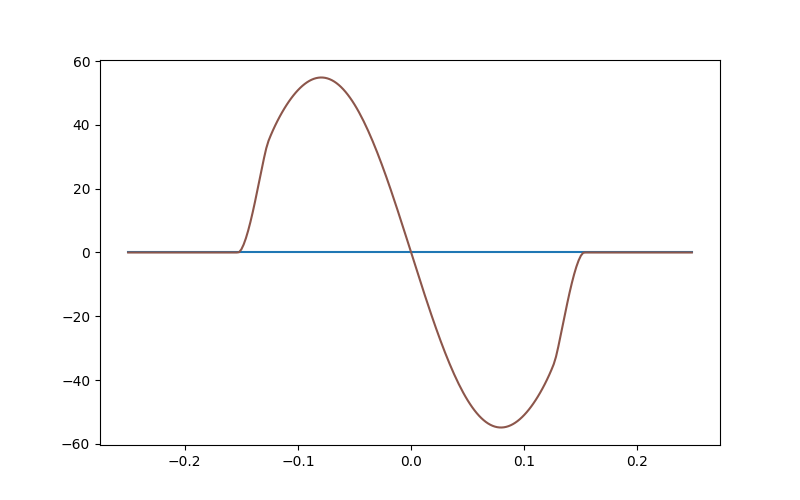

In [75]:
lam = parameter_values['lambda']
per = parameter_values['P']
ecc = parameter_values['e']
inc = parameter_values['i']
omega = parameter_values['omega']
tc = parameter_values['Tc']
sma = parameter_values['a_Rs']
beta0 = 1.5 #natural broadening
ld_c1 = parameter_values['ld_coeff'][0]
ld_c2 = parameter_values['ld_coeff'][1]
Vsini = parameter_values['v_sini']
sigma0 = 8.0 / 2.335
zeta = 2.0
Kmax = 6
Rp =  parameter_values['R_Rs'] 

res1 = pyarome.RM(lam,x0,per,inc,ecc,omega,tc,sma,ld_c1,ld_c2,beta0,Vsini,4.5,zeta,Kmax,Rp)
res2 = pyarome.RM(lam,x0,per,inc,ecc,omega,tc,sma,ld_c1,ld_c2,beta0,Vsini,8,zeta,Kmax,Rp)
res3 = pyarome.RM(lam,x0,per,inc,ecc,omega,tc,sma,ld_c1,ld_c2,beta0,Vsini,12,zeta,Kmax,Rp)

import matplotlib
matplotlib.use('TkAgg'),
import matplotlib.pyplot as plt
%matplotlib notebook

plt.figure(figsize=(8,5))
plt.plot(x0, model_noCB)#
#plt.plot(x0, model_withCB)#
#plt.plot(x0, model_ohta, c='C4')
plt.plot(x0, res1[0]*1000, c='C5')
#plt.plot(x0, res2[0]*1000, c='C6')
#plt.plot(x0, res3[0]*1000, c='C7')
#plt.plot(x0, res[0]*1000, c='C5')
#plt.scatter(x0, cont_Val)
plt.show()

#print(res)

In [64]:
print(model_noCB)

[  0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.         17.19309     0.         23.59052
  26.74844    29.722853   32.095577   33.96253    35.740433   37.4317
  39.04583    40.58268    42.086784   43.55368    44.94188    46.287006
  47.58936    48.83051    50.014946   51.144115   52.228676   53.231396
  54.120724   54.97557    55.730164   56.418037   57.050976   57.596043
  58.04679    58.438015   58.667324   58.82249   

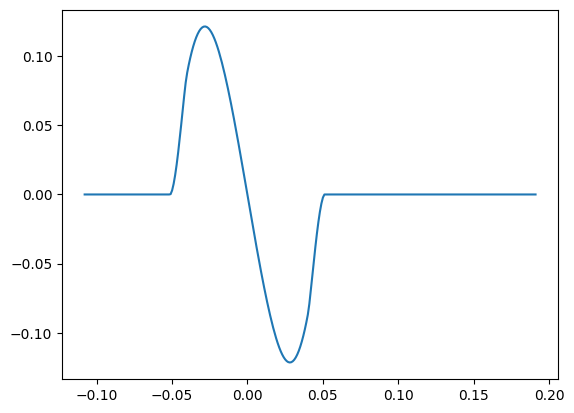

In [7]:
# import numpy as np
from pylab import plot,show

beta0  =  1.68
Vsini  = 5.3
sigma0 =  4.0
zeta   =  2.0
Rp     =  0.1135
Kmax = 4

per = 2.516729
tc  = 2455818.40790 - 2454000
sma = 8.61
Rp = 0.1135
inc = 88.7
ecc = 0.00
omega = 90 

K = 196.8/1e3

Vsini=10.0
zeta=2.0
lam = 0

t = np.arange(1818.3,  1818.6, 0.001)

res = pyarome.RM(lam,t,per,inc,ecc,omega,tc,sma,0.69,0.0,beta0,Vsini,sigma0,zeta,Kmax,Rp)

plot(t, res[1])
show()

In [ ]:
 x = x+np.ones(len(x))*dT0
arome(y*360.+90., sma, inc, lda, np.array([ldc1, ldc2]), beta0, Vsini, sigma0, zeta, rp, Kmax, units='degree')